In [3]:
!pip install newspaper3k scikit-learn pandas numpy matplotlib seaborn transformers sentence-transformers

In [6]:
import pandas as pd

# Load JSON lines file
data_path = '/content/News_Category_Dataset_v3.json'
df = pd.read_json(data_path, lines=True)

# Keep only relevant columns and rename
df = df[['headline', 'short_description', 'category']]
df = df.rename(columns={'headline': 'title', 'short_description': 'text'})

# Clean up
df = df.drop_duplicates(subset='title').reset_index(drop=True)
df = df.head(100)  # Use a sample of 100 for now

# Preview
df.head()

,title,text,category
0,Over 4 Million Americans Roll Up Sleeves For O...,Health experts said it is too early to predict...,U.S. NEWS
1,"American Airlines Flyer Charged, Banned For Li...",He was subdued by passengers and crew when he ...,U.S. NEWS
2,23 Of The Funniest Tweets About Cats And Dogs ...,"""Until you have a dog you don't understand wha...",COMEDY
3,The Funniest Tweets From Parents This Week (Se...,"""Accidentally put grown-up toothpaste on my to...",PARENTING
4,Woman Who Called Cops On Black Bird-Watcher Lo...,Amy Cooper accused investment firm Franklin Te...,U.S. NEWS


In [7]:
import numpy as np

# Simulate 10 fake users
user_ids = [f"user_{i}" for i in range(1, 11)]

# Simulate interactions: rows = user_id, columns = article_index, value = 1 (clicked) or 0 (not clicked)
interaction_data = []

np.random.seed(42)  # reproducible results

for user in user_ids:
    clicked_articles = np.random.choice(df.index, size=10, replace=False)  # 10 random articles per user
    for idx in df.index:
        interaction = 1 if idx in clicked_articles else 0
        interaction_data.append((user, idx, interaction))

# Convert to DataFrame
interactions_df = pd.DataFrame(interaction_data, columns=['user_id', 'article_id', 'clicked'])

# Preview
interactions_df.head(10)

,user_id,article_id,clicked
0,user_1,0,1
1,user_1,1,0
2,user_1,2,0
3,user_1,3,0
4,user_1,4,0
5,user_1,5,0
6,user_1,6,0
7,user_1,7,0
8,user_1,8,0
9,user_1,9,0


In [8]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder

# Create the user-item matrix
interaction_matrix = pd.pivot_table(interactions_df, values='clicked', index='user_id', columns='article_id', fill_value=0)

# Calculate similarity between users
cosine_sim = cosine_similarity(interaction_matrix)

# Convert to DataFrame for easy access
cosine_sim_df = pd.DataFrame(cosine_sim, index=interaction_matrix.index, columns=interaction_matrix.index)

# Function to get recommendations for a user
def get_user_recommendations(user_id, top_n=5):
    # Get similar users (user_id -> row in cosine similarity matrix)
    similar_users = cosine_sim_df[user_id].sort_values(ascending=False)[1:top_n+1].index

    # Collect all articles clicked by similar users
    similar_user_articles = interactions_df[interactions_df['user_id'].isin(similar_users) & (interactions_df['clicked'] == 1)]

    # Get recommended articles (remove already clicked ones)
    recommended_articles = df[~df.index.isin(similar_user_articles['article_id'])].head(top_n)

    return recommended_articles[['title', 'category']]

# Example: Get recommendations for 'user_1'
user_recommendations = get_user_recommendations('user_1')
user_recommendations

,title,category
1,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS
2,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY
5,Cleaner Was Dead In Belk Bathroom For 4 Days B...,U.S. NEWS
7,Puerto Ricans Desperate For Water After Hurric...,WORLD NEWS
11,Man Sets Himself On Fire In Apparent Protest O...,WORLD NEWS


In [9]:
from sentence_transformers import SentenceTransformer
import numpy as np

# Load a pre-trained BERT model
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

# Create embeddings for titles and descriptions
df['embedding'] = df['text'].apply(lambda x: model.encode(x))

# Function to get recommendations based on content similarity
def get_content_based_recommendations(user_id, top_n=5):
    # Get the articles clicked by the user
    clicked_articles = interactions_df[(interactions_df['user_id'] == user_id) & (interactions_df['clicked'] == 1)]['article_id']

    # Get embeddings for clicked articles
    clicked_embeddings = np.array([df.loc[article_id, 'embedding'] for article_id in clicked_articles])

    # Calculate similarity between clicked articles and all articles in the dataset
    article_embeddings = np.array(df['embedding'].tolist())
    similarities = cosine_similarity(clicked_embeddings, article_embeddings)

    # Average similarity across all clicked articles
    avg_similarity = similarities.mean(axis=0)

    # Get top N recommended articles based on similarity
    recommended_indices = avg_similarity.argsort()[-top_n:][::-1]

    # Return recommended articles
    return df.iloc[recommended_indices][['title', 'category']]

# Example: Get content-based recommendations for 'user_1'
content_based_recommendations = get_content_based_recommendations('user_1')
content_based_recommendations

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.51k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

,title,category
44,Mark Meadows Complies With Justice Dept. Subpo...,POLITICS
45,"Meet Alex Aster, The TikToker Changing The Pub...",CULTURE & ARTS
22,Hurricane Fiona Bears Down On Dominican Republ...,WORLD NEWS
70,9/11 Attacks Still Reverberate As U.S. Marks 2...,U.S. NEWS
53,Possible Nationwide Rail Strike Is Already Imp...,U.S. NEWS


In [13]:
# Ensure both DataFrames contain the 'category' column
def get_combined_recommendations(user_id, collaborative_weight=0.5, content_weight=0.5, top_n=5):
    # Get collaborative recommendations
    collaborative_recs = get_user_recommendations(user_id, top_n)
    print("Collaborative Recommendations:")
    print(collaborative_recs.head())  # Debug: Check the structure of collaborative recommendations

    collaborative_recs['source'] = 'collaborative'

    # Get content-based recommendations
    content_recs = get_content_based_recommendations(user_id, top_n)
    print("Content-Based Recommendations:")
    print(content_recs.head())  # Debug: Check the structure of content-based recommendations

    content_recs['source'] = 'content-based'

    # Ensure both dataframes have the 'category' column and same naming
    collaborative_recs = collaborative_recs.rename(columns={'category': 'category_collab'})
    content_recs = content_recs.rename(columns={'category': 'category_content'})

    # Merge both recommendations on 'title'
    merged_recs = pd.merge(collaborative_recs[['title', 'category_collab', 'source']],
                           content_recs[['title', 'category_content', 'source']],
                           on='title',
                           how='outer',
                           suffixes=('_collab', '_content'))

    # Add weighted score (collaborative + content-based)
    merged_recs['combined_score'] = collaborative_weight * merged_recs.index + content_weight * merged_recs.index

    # Sort by combined score and select top N
    top_recs = merged_recs.sort_values(by='combined_score', ascending=False).head(top_n)

    return top_recs[['title', 'category_collab', 'category_content']]

# Example: Get combined recommendations for 'user_1'
combined_recommendations = get_combined_recommendations('user_1')
combined_recommendations

Collaborative Recommendations:
                                                title    category
1   American Airlines Flyer Charged, Banned For Li...   U.S. NEWS
2   23 Of The Funniest Tweets About Cats And Dogs ...      COMEDY
5   Cleaner Was Dead In Belk Bathroom For 4 Days B...   U.S. NEWS
7   Puerto Ricans Desperate For Water After Hurric...  WORLD NEWS
11  Man Sets Himself On Fire In Apparent Protest O...  WORLD NEWS
Content-Based Recommendations:
                                                title        category
44  Mark Meadows Complies With Justice Dept. Subpo...        POLITICS
45  Meet Alex Aster, The TikToker Changing The Pub...  CULTURE & ARTS
22  Hurricane Fiona Bears Down On Dominican Republ...      WORLD NEWS
70  9/11 Attacks Still Reverberate As U.S. Marks 2...       U.S. NEWS
53  Possible Nationwide Rail Strike Is Already Imp...       U.S. NEWS


,title,category_collab,category_content
9,Puerto Ricans Desperate For Water After Hurric...,WORLD NEWS,NaN
8,Possible Nationwide Rail Strike Is Already Imp...,NaN,U.S. NEWS
7,"Meet Alex Aster, The TikToker Changing The Pub...",NaN,CULTURE & ARTS
6,Mark Meadows Complies With Justice Dept. Subpo...,NaN,POLITICS
5,Man Sets Himself On Fire In Apparent Protest O...,WORLD NEWS,NaN


In [14]:
# Testing the system for multiple users
users = ['user_1', 'user_2', 'user_3']  # List of sample users

# Display recommendations for each user
for user in users:
    print(f"Recommendations for {user}:")
    recs = get_combined_recommendations(user)
    print(recs)
    print("\n")

Recommendations for user_1:
Collaborative Recommendations:
                                                title    category
1   American Airlines Flyer Charged, Banned For Li...   U.S. NEWS
2   23 Of The Funniest Tweets About Cats And Dogs ...      COMEDY
5   Cleaner Was Dead In Belk Bathroom For 4 Days B...   U.S. NEWS
7   Puerto Ricans Desperate For Water After Hurric...  WORLD NEWS
11  Man Sets Himself On Fire In Apparent Protest O...  WORLD NEWS
Content-Based Recommendations:
                                                title        category
44  Mark Meadows Complies With Justice Dept. Subpo...        POLITICS
45  Meet Alex Aster, The TikToker Changing The Pub...  CULTURE & ARTS
22  Hurricane Fiona Bears Down On Dominican Republ...      WORLD NEWS
70  9/11 Attacks Still Reverberate As U.S. Marks 2...       U.S. NEWS
53  Possible Nationwide Rail Strike Is Already Imp...       U.S. NEWS
                                               title category_collab  \
9  Puerto Ricans Despe

Collaborative Recommendations:
                                                title    category
1   American Airlines Flyer Charged, Banned For Li...   U.S. NEWS
2   23 Of The Funniest Tweets About Cats And Dogs ...      COMEDY
5   Cleaner Was Dead In Belk Bathroom For 4 Days B...   U.S. NEWS
7   Puerto Ricans Desperate For Water After Hurric...  WORLD NEWS
11  Man Sets Himself On Fire In Apparent Protest O...  WORLD NEWS
Content-Based Recommendations:
                                                title        category
44  Mark Meadows Complies With Justice Dept. Subpo...        POLITICS
45  Meet Alex Aster, The TikToker Changing The Pub...  CULTURE & ARTS
22  Hurricane Fiona Bears Down On Dominican Republ...      WORLD NEWS
70  9/11 Attacks Still Reverberate As U.S. Marks 2...       U.S. NEWS
53  Possible Nationwide Rail Strike Is Already Imp...       U.S. NEWS


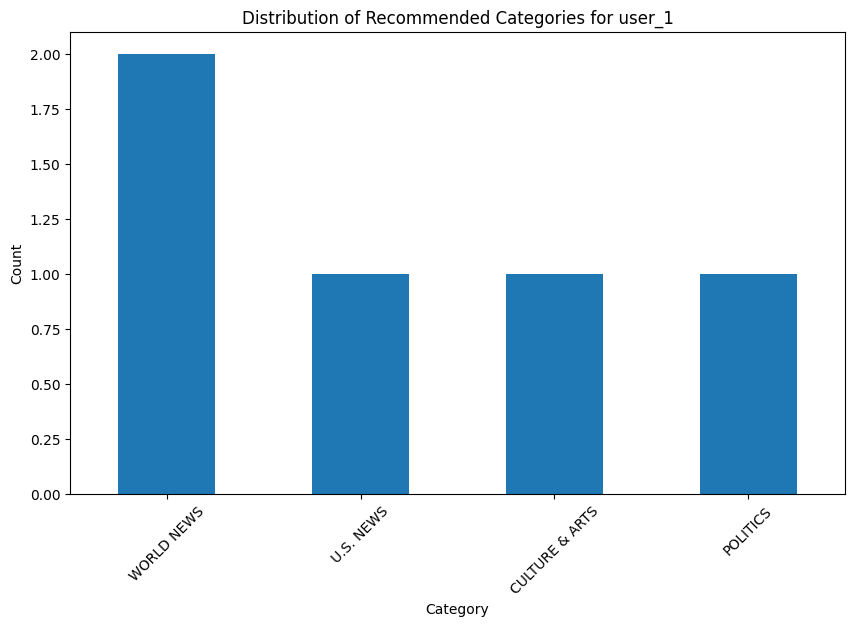

In [15]:
import matplotlib.pyplot as plt

# Example: Visualization of recommended categories for user_1
user_recs = get_combined_recommendations('user_1')

# Combine the categories from both collaborative and content-based recommendations
combined_categories = user_recs[['category_collab', 'category_content']].stack()

# Plot the distribution of categories
plt.figure(figsize=(10, 6))
combined_categories.value_counts().plot(kind='bar')
plt.title('Distribution of Recommended Categories for user_1')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()